# OBJETIVO DESSE EXERCICIO: 
* Entender como os dados se comportam ao longo do tempo em um sistema de aluguel de bikes

In [ ]:
create schema bikes;


In [ ]:
use bikes;

In [ ]:
CREATE TABLE TB_BIKES (
  `duracao_segundos` int DEFAULT NULL,
  `data_inicio` text,
  `data_fim` text,
  `numero_estacao_inicio` int DEFAULT NULL,
  `estacao_inicio` text,
  `numero_estacao_fim` int DEFAULT NULL,
  `estacao_fim` text,
  `numero_bike` text,
  `tipo_membro` text);

In [ ]:
Get-Content "C:\Users\lucas\OneDrive\Desktop\analise_dados\exercicios\window_functions\import_dados.sql" | mysql -u root -p --local-infile=1 bikes

In [ ]:
SELECT * FROM TB_BIKES LIMIT 30;

# SOMA MOVEL

In [ ]:
# Duracao total do aluguel das bikes (em horas)

SELECT SUM(duracao_segundos) / 3600 AS duracao_total_horas
FROM TB_BIKES;

In [ ]:
-- Duracao total do aluguel das bikes (em horas) ao longo do tempo (soma acumulada)

SELECT duracao_segundos,
    SUM(duracao_segundos/3600) OVER (ORDER BY data_inicio) AS duracao_total_horas
FROM TB_BIKES;

In [ ]:
-- Duracao total do aluguel das bikes(em horas), ao longo do tempo, por estacao de inicio
-- quando a data de inicio for inferior a 2012-01-08

SELECT data_inicio, estacao_inicio,
    SUM(duracao_segundos/3600) OVER (PARTITION BY estacao_inicio ORDER BY data_inicio) AS duracao_total_horas
FROM TB_BIKES
WHERE data_inicio < '2012-01-08';

# MEDIA MOVEL

In [ ]:
# Qual a média de tempo (em horas) de aluguel de bike da estação de início 31017?
SELECT estacao_inicio,
       AVG(duracao_segundos/60/60) AS media_tempo_aluguel
FROM TB_BIKES
WHERE numero_estacao_inicio = 31017
GROUP BY estacao_inicio;

In [ ]:
# Qual a média de tempo (em horas) de aluguel da estação de início 31017, ao longo do tempo (média móvel)?
SELECT estacao_inicio,
       AVG(duracao_segundos/60/60) OVER (PARTITION BY estacao_inicio ORDER BY data_inicio) AS media_tempo_aluguel
FROM TB_BIKES
WHERE numero_estacao_inicio = 31017;

# Exercicios

In [ ]:
# Retornar:
# Estação de início, data de início e duração de cada aluguel de bike em segundos
# Duração total de aluguel das bikes ao longo do tempo por estação de início
# Duração média do aluguel de bikes ao longo do tempo por estação de início
# Número de aluguéis de bikes por estação ao longo do tempo 
# Somente os registros quando a data de início for inferior a '2012-01-08'

SELECT estacao_inicio,
       data_inicio,
       duracao_segundos,
       SUM(duracao_segundos/60/60) OVER (PARTITION BY estacao_inicio ORDER BY data_inicio) AS duracao_total_aluguel,
       AVG(duracao_segundos/60/60) OVER (PARTITION BY estacao_inicio ORDER BY data_inicio) AS media_tempo_aluguel,
       COUNT(duracao_segundos/60/60) OVER (PARTITION BY estacao_inicio ORDER BY data_inicio) AS numero_alugueis
FROM TB_BIKES
WHERE data_inicio < '2012-01-08';

In [ ]:
# Retornar:
# Estação de início, data de início de cada aluguel de bike e duração de cada aluguel em segundos
# Número de aluguéis de bikes (independente da estação) ao longo do tempo (nao precisa de particionamento)
# Somente os registros quando a data de início for inferior a '2012-01-08'

SELECT estacao_inicio,
       data_inicio,
       duracao_segundos,
       COUNT(*) OVER (ORDER BY data_inicio) AS numero_alugueis
FROM TB_BIKES
WHERE data_inicio < '2012-01-08';

# ROW NUMBER - contagem ao longo do tempo, melhor performance que COUNT(*)

In [ ]:

SELECT estacao_inicio,
       data_inicio,
       duracao_segundos,
       ROW_NUMBER() OVER (ORDER BY data_inicio) AS numero_alugueis
FROM TB_BIKES
WHERE data_inicio < '2012-01-08';

In [ ]:
-- E se quisermos o mesmo resultado anterior, mas a contagem por estação?

-- COLOCAMOS O PARTITION PRA SEPARAR POR TODAS AS ESTACOES

SELECT estacao_inicio,
       data_inicio,
       duracao_segundos,
       ROW_NUMBER() OVER (PARTITION BY estacao_inicio ORDER BY data_inicio) AS numero_alugueis
FROM TB_BIKES
WHERE data_inicio < '2012-01-08';



# CLASSIFICANDO OS DADOS EM RANKING 

# DENSE RANK ( mais usado)

* Mais simples de entender

In [ ]:

# Estação, data de início, duração em segundos do aluguel e número de aluguéis ao longo do tempo
# para a estação de id 31000, com a coluna de data_inicio convertida para o formato date
# Queremos a ordem (classificação ou ranking) dos dias de aluguel ao longo do tempo
# DENSE_RANK() concede todas as linhas idênticas a mesma classificação (ranking) e salta para o próximo item no ranking

SELECT estacao_inicio,
       CAST(data_inicio as date),
       duracao_segundos,
       DENSE_RANK() OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS ranking_aluguel
FROM TB_BIKES
WHERE data_inicio < '2012-01-08'
AND numero_estacao_inicio = 31000;

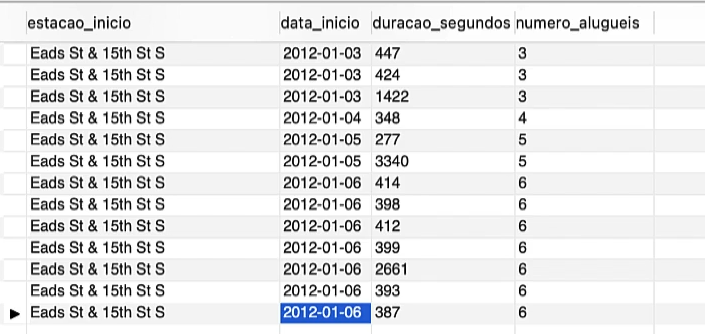

# RANK 
* Mais dificil de compreender, pula os numeros das classificacoes

In [ ]:
# Estação, data de início, duração em segundos do aluguel e número de aluguéis ao longo do tempo
# para a estação de id 31000, com a coluna de data_inicio convertida para o formato date
# Queremos a ordem (classificação ou ranking) dos dias de aluguel ao longo do tempo
# RANK() concede todas as linhas idênticas a mesma classificação (ranking) e salta para o próximo item no ranking
SELECT estacao_inicio,
       CAST(data_inicio as date),
       duracao_segundos,
       RANK() OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS ranking_aluguel
FROM TB_BIKES
WHERE data_inicio < '2012-01-08'
AND numero_estacao_inicio = 31000;


# MISTURANDO AS FUNCOES

In [ ]:
# Comparando as funções
SELECT estacao_inicio,
       CAST(data_inicio as date) AS data_inicio,
       duracao_segundos,
       ROW_NUMBER() OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS numero_alugueis,
       DENSE_RANK() OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS ranking_aluguel_dense_rank,
       RANK() OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS ranking_aluguel_rank
FROM TB_BIKES
WHERE data_inicio < '2012-01-08'
AND numero_estacao_inicio = 31000


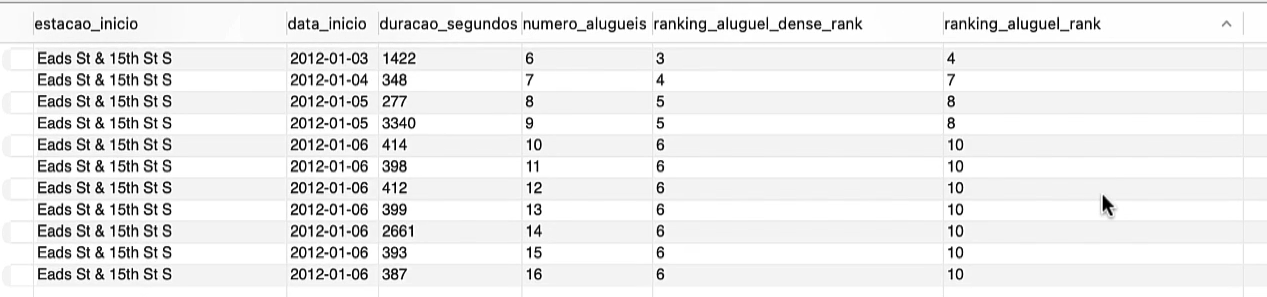

# NTILE 

* A função NTILE() é uma função de janela (window) que distribui linhas de uma partição ordenada em um número predefinido 
* de grupos aproximadamente iguais. A função atribui a cada grupo um número a partir de 1. 

In [ ]:


SELECT estacao_inicio,
       duracao_segundos,
       ROW_NUMBER() OVER (PARTITION BY estacao_inicio ORDER BY duracao_segundos) AS numero_alugueis,
       NTILE(2) OVER (PARTITION BY estacao_inicio ORDER BY duracao_segundos) AS numero_grupo_dois,
       NTILE(4) OVER (PARTITION BY estacao_inicio ORDER BY duracao_segundos) AS numero_grupo_quatro,
       NTILE(5) OVER (PARTITION BY estacao_inicio ORDER BY duracao_segundos) AS numero_grupo_cinco
FROM cap06.TB_BIKES
WHERE data_inicio < '2012-01-08'
AND numero_estacao_inicio = 31000;

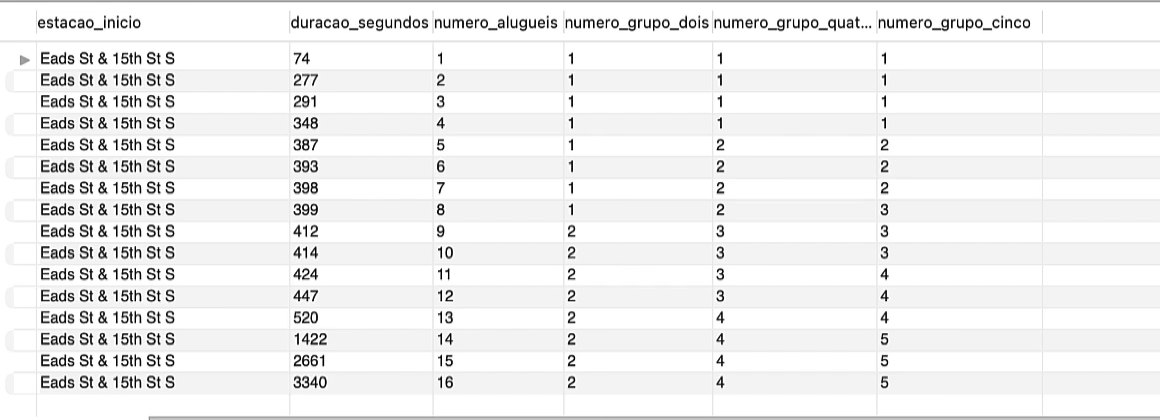

In [ ]:
SELECT estacao_inicio,
       CAST(data_inicio as date) AS data_inicio,
       duracao_segundos,
       ROW_NUMBER() OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS numero_alugueis,
       NTILE(1) OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS numero_grupo,
       NTILE(4) OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS numero_grupo,
       NTILE(16) OVER (PARTITION BY estacao_inicio ORDER BY CAST(data_inicio as date)) AS numero_grupo
FROM cap06.TB_BIKES
WHERE data_inicio < '2012-01-08'
AND numero_estacao_inicio = 31000;

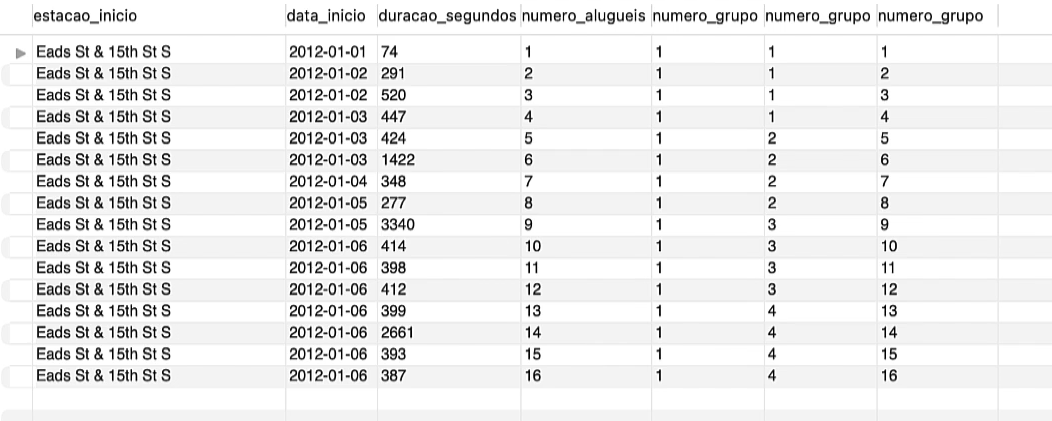